# Limpieza de datos - Clustering de Usuarios

Este notebook realiza la limpieza de datos específica para el **proyecto de clustering de usuarios**. A diferencia del proyecto de regresión, aquí:

- ✅ **CustomerID nulos**: Se ELIMINAN (requisito obligatorio - sin cliente no hay cluster)
- ✅ **Description nulas**: Se ELIMINAN (sin descripción no hay info del producto)
- ✅ **Cancelaciones**: Se CONSERVAN (la tasa de devolución es un patrón de comportamiento)
- ✅ **Outliers**: Capping al p99 (balance entre mantener datos y reducir extremos)

## Anomalías identificadas en el EDA:
- Registros duplicados
- Transacciones sin identificación de usuario (CustomerID nulo)
- Cantidades y precios unitarios negativos o cero
- Outliers en cantidades y precios unitarios
- StockCodes no estándar (códigos operacionales)

## 0. Imports y Carga del Dataset

Preparamos el entorno de trabajo: importamos librerías, configuramos la estética visual, definimos las rutas del proyecto y cargamos el dataset original. 

A continuación creamos las columnas auxiliares necesarias para los pasos de limpieza:
- `Fecha`: fecha sin hora (normalizada)
- `Mes`: periodo mensual
- `DiaSemana`: nombre del día de la semana
- `EsCancelacion`: booleano si el InvoiceNo empieza con 'C'
- `TotalPrice`: cantidad × precio unitario

Inicializamos el diccionario de auditoría `stats_cleaning` que registrará paso a paso cuántos registros eliminamos y por qué.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

# Rutas del proyecto
RUTA_CSV      = '../../../data/raw/data.csv'
RUTA_GRAFICOS = '../../../graphics/gr_clustering/clean/'
RUTA_INTERIM  = '../../../data/interim/interim_ProyClustering/'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)
os.makedirs(RUTA_INTERIM,  exist_ok=True)

print('Librerías cargadas correctamente.')
print(f'Rutas configuradas:')
print(f'  - CSV raw    : {RUTA_CSV}')
print(f'  - Gráficos   : {RUTA_GRAFICOS}')
print(f'  - Interim    : {RUTA_INTERIM}')

Librerías cargadas correctamente.
Rutas configuradas:
  - CSV raw    : ../../../data/raw/data.csv
  - Gráficos   : ../../../gr_clustering/clean/
  - Interim    : ../../../data/interim/interim_ProyClustering/


In [38]:
# Carga del dataset original
df_raw     = pd.read_csv(RUTA_CSV, encoding='latin-1')
df_working = df_raw.copy()

# ── Columnas auxiliares ────────────────────────────────────────────────────────
df_working['InvoiceDate']   = pd.to_datetime(df_working['InvoiceDate'], format='mixed')
df_working['Fecha']         = df_working['InvoiceDate'].dt.normalize()
df_working['Mes']           = df_working['InvoiceDate'].dt.to_period('M')
df_working['DiaSemana']     = df_working['InvoiceDate'].dt.day_name()
df_working['EsCancelacion'] = df_working['InvoiceNo'].str.startswith('C')
df_working['TotalPrice']    = df_working['Quantity'] * df_working['UnitPrice']

# ── Diccionario de auditoría (se actualiza en cada paso) ──────────────────────
stats_cleaning = {'Registros Iniciales': len(df_raw)}

# ── Resumen de carga ──────────────────────────────────────────────────────────
print('=' * 55)
print(f'  DATASET CARGADO - CLUSTERING DE USUARIOS')
print('=' * 55)
print(f'  Filas    : {df_raw.shape[0]:>10,}')
print(f'  Columnas : {df_raw.shape[1]:>10}')
print('=' * 55)
print(f'\n  df_working activo : {len(df_working):,} filas')
print(f'  Columnas auxiliares añadidas:')
print(f'    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice')
print(f'\n  Columnas originales: {list(df_raw.columns)}')

  DATASET CARGADO - CLUSTERING DE USUARIOS
  Filas    :    541,909
  Columnas :          8

  df_working activo : 541,909 filas
  Columnas auxiliares añadidas:
    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice

  Columnas originales: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [39]:
# ── Inspección inicial de valores nulos ───────────────────────────────────────
print('\n' + '=' * 55)
print('  VALORES NULOS INICIALES')
print('=' * 55)

nulos_count = df_working.isnull().sum()
nulos_pct = (df_working.isnull().sum() / len(df_working) * 100).round(2)
nulos_df = pd.DataFrame({
    'Nulos': nulos_count,
    'Porcentaje': nulos_pct
})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(nulos_df) > 0:
    print(f'\n  Columnas con valores nulos:')
    for col, row in nulos_df.iterrows():
        print(f"    {col:<15} : {row['Nulos']:>10,} ({row['Porcentaje']:>6.2f}%)")
else:
    print(f'\n  ✓ No hay valores nulos en el dataset')

print(f'\n  ⚠ CRÍTICO para clustering: CustomerID tiene {nulos_df.loc["CustomerID", "Nulos"] if "CustomerID" in nulos_df.index else 0:,} nulos → DEBEN ser eliminados')


  VALORES NULOS INICIALES

  Columnas con valores nulos:
    CustomerID      :  135,080.0 ( 24.93%)
    Description     :    1,454.0 (  0.27%)

  ⚠ CRÍTICO para clustering: CustomerID tiene 135,080 nulos → DEBEN ser eliminados


---
# 3. LIMPIEZA DE DATOS

A continuación se ejecutan los pasos de limpieza secuencialmente, actualizando el diccionario `stats_cleaning` en cada paso para mantener la auditoría completa del proceso.

### 3.1 Eliminar duplicados exactos

Una fila duplicada exacta tiene **todos** sus campos idénticos: mismo `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `UnitPrice`, `InvoiceDate`, `CustomerID` y `Country`. 

**Justificación**: Esto es físicamente imposible en un sistema transaccional real — su presencia indica errores de doble inserción en la base de datos, exports corruptos o fallos de ETL. 

Se conserva la primera ocurrencia (`keep='first'`) al ser todas idénticas.

In [40]:
# 3.1 — Eliminar duplicados exactos
antes = len(df_working)
df_working = df_working.drop_duplicates(keep='first', ignore_index=True)
eliminadas_dup = antes - len(df_working)
stats_cleaning['Duplicados eliminados'] = eliminadas_dup

print(f"{'='*60}")
print(f"  3.1 — ELIMINAR DUPLICADOS EXACTOS")
print(f"{'='*60}")
print(f"  Justificación: Errores de inserción en BD/ETL")
print(f"  Estrategia   : Conservar primera ocurrencia (keep='first')")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_dup:>10,}")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : duplicados restantes = {df_working.duplicated().sum()}")
print(f"{'='*60}")

  3.1 — ELIMINAR DUPLICADOS EXACTOS
  Justificación: Errores de inserción en BD/ETL
  Estrategia   : Conservar primera ocurrencia (keep='first')

  Filas antes     :    541,909
  Filas eliminadas:      5,268
  Filas después   :    536,641
  Verificación    : duplicados restantes = 0


### 3.2 Eliminar negativos huérfanos

Son filas con `Quantity < 0` pero **sin prefijo `C`** en `InvoiceNo`. En este dataset son ajustes internos de almacén (descripciones como "faulty", "damages", "check", "reverse adjustment"). 

**Justificación**: El análisis del CSV confirma que el **100%** cumple simultáneamente:
- `UnitPrice = 0.0` → `TotalPrice = 0` siempre, sin impacto en ventas
- `CustomerID = NaN` → ninguna tiene cliente asociado
- Sin prefijo `C` → el sistema nunca las registró como cancelación oficial

**Decisión**: No son cancelaciones de venta ni transacciones recuperables. No tienen cliente identificado → no aportan valor al clustering. Se eliminan.

In [41]:
# 3.2 — Eliminar negativos huérfanos (ajustes internos de almacén)
antes = len(df_working)
mask_huerfanos = (
    ~df_working['InvoiceNo'].str.startswith('C', na=False) &
    (df_working['Quantity'] < 0) &
    (df_working['UnitPrice'] == 0.0)
)
df_working = df_working[~mask_huerfanos].reset_index(drop=True)
eliminadas_huerfanos = antes - len(df_working)
stats_cleaning['Negativos huérfanos eliminados'] = eliminadas_huerfanos

print(f"{'='*60}")
print(f"  3.2 — ELIMINAR NEGATIVOS HUÉRFANOS")
print(f"{'='*60}")
print(f"  Justificación: Ajustes internos sin valor")
print(f"               : sin C + Qty<0 + Price=0 → sin cliente")
print(f"  Criterio     : ~InvoiceNo.startswith('C') & Quantity<0 & UnitPrice==0")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_huerfanos:>10,}")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : huérfanos restantes = {(~df_working['InvoiceNo'].str.startswith('C', na=False) & (df_working['Quantity'] < 0) & (df_working['UnitPrice'] == 0.0)).sum()}")
print(f"{'='*60}")

  3.2 — ELIMINAR NEGATIVOS HUÉRFANOS
  Justificación: Ajustes internos sin valor
               : sin C + Qty<0 + Price=0 → sin cliente
  Criterio     : ~InvoiceNo.startswith('C') & Quantity<0 & UnitPrice==0

  Filas antes     :    536,641
  Filas eliminadas:      1,336
  Filas después   :    535,305
  Verificación    : huérfanos restantes = 0


### 3.3 Eliminar StockCodes no estándar

Los códigos de producto comerciales siguen el patrón `DDDDD[LL]` (5 dígitos + hasta 2 letras opcionales, ej: `22423`, `85123A`, `15056BL`).

**Justificación**: Códigos como `POST`, `DOT`, `D`, `M`, `BANK CHARGES`, `AMAZONFEE`, `C2` son códigos operacionales (portes, descuentos, comisiones, ajustes manuales) que **no representan ventas de productos reales**.

**Decisión**: Para clustering de usuarios por comportamiento de compra, necesitamos solo productos físicos reales. Los códigos operacionales no aportan patrones de consumo válidos. Se eliminan.

In [42]:
# 3.3 — Eliminar StockCodes no estándar
# Patrón: 5 dígitos + hasta 2 letras opcionales (cubre variantes como 15056BL)
PATRON_STOCK = r'^[0-9]{5}[A-Za-z]{0,2}$'

antes = len(df_working)
mask_estandar = df_working['StockCode'].str.match(PATRON_STOCK, na=False)
df_working = df_working[mask_estandar].reset_index(drop=True)
eliminadas_stock = antes - len(df_working)
stats_cleaning['StockCodes no estándar eliminados'] = eliminadas_stock

print(f"{'='*60}")
print(f"  3.3 — ELIMINAR STOCKCODES NO ESTÁNDAR")
print(f"{'='*60}")
print(f"  Justificación: Códigos operacionales no son productos reales")
print(f"               : Ejemplos: POST, DOT, BANK CHARGES, AMAZONFEE")
print(f"  Patrón válido: {PATRON_STOCK}")
print(f"               : 5 dígitos + hasta 2 letras opcionales")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_stock:>10,}")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : no estándar restantes = {(~df_working['StockCode'].str.match(PATRON_STOCK, na=False)).sum()}")
print(f"{'='*60}")

  3.3 — ELIMINAR STOCKCODES NO ESTÁNDAR
  Justificación: Códigos operacionales no son productos reales
               : Ejemplos: POST, DOT, BANK CHARGES, AMAZONFEE
  Patrón válido: ^[0-9]{5}[A-Za-z]{0,2}$
               : 5 dígitos + hasta 2 letras opcionales

  Filas antes     :    535,305
  Filas eliminadas:      2,977
  Filas después   :    532,328
  Verificación    : no estándar restantes = 0


### 3.4 Eliminar filas con Quantity = 0

Filas con `Quantity = 0` no representan ninguna transacción real (ni venta ni devolución) y su `TotalPrice` es siempre 0.

**Justificación**: Estas filas son registros incompletos o errores del sistema que no aportan información sobre el comportamiento de compra del usuario. 

**Decisión**: Para clustering necesitamos transacciones reales con cantidad efectiva (positiva o negativa en caso de cancelaciones). Se eliminan.

In [43]:
# 3.4 — Eliminar filas con Quantity = 0
antes = len(df_working)
df_working = df_working[df_working['Quantity'] != 0].reset_index(drop=True)
eliminadas_qty0 = antes - len(df_working)
stats_cleaning['Quantity = 0 eliminados'] = eliminadas_qty0

print(f"{'='*60}")
print(f"  3.4 — ELIMINAR QUANTITY = 0")
print(f"{'='*60}")
print(f"  Justificación: No representan transacción real")
print(f"               : Ni compra ni devolución → TotalPrice = 0")
print(f"  Criterio     : Quantity != 0")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_qty0:>10,}")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : Quantity = 0 restantes = {(df_working['Quantity'] == 0).sum()}")
print(f"{'='*60}")

  3.4 — ELIMINAR QUANTITY = 0
  Justificación: No representan transacción real
               : Ni compra ni devolución → TotalPrice = 0
  Criterio     : Quantity != 0

  Filas antes     :    532,328
  Filas eliminadas:          0
  Filas después   :    532,328
  Verificación    : Quantity = 0 restantes = 0


### 3.5 Eliminar filas con UnitPrice = 0

Filas con `UnitPrice = 0` son transacciones sin valor económico. Su `TotalPrice` es siempre 0 independientemente de la cantidad.

**Justificación**: Estas transacciones no aportan información sobre el gasto o inversión del usuario, que es una dimensión clave para segmentar por comportamiento de compra.

**Decisión**: Para clustering necesitamos transacciones con valor real que reflejen el poder adquisitivo y patrones de gasto de cada usuario. Se eliminan.

In [44]:
# 3.5 — Eliminar filas con UnitPrice = 0
antes = len(df_working)
df_working = df_working[df_working['UnitPrice'] > 0].reset_index(drop=True)
eliminadas_price0 = antes - len(df_working)
stats_cleaning['UnitPrice = 0 eliminados'] = eliminadas_price0

print(f"{'='*60}")
print(f"  3.5 — ELIMINAR UNITPRICE = 0")
print(f"{'='*60}")
print(f"  Justificación: Transacciones sin valor económico")
print(f"               : No reflejan gasto real del usuario")
print(f"  Criterio     : UnitPrice > 0")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_price0:>10,}")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : UnitPrice = 0 restantes = {(df_working['UnitPrice'] == 0).sum()}")
print(f"{'='*60}")

  3.5 — ELIMINAR UNITPRICE = 0
  Justificación: Transacciones sin valor económico
               : No reflejan gasto real del usuario
  Criterio     : UnitPrice > 0

  Filas antes     :    532,328
  Filas eliminadas:      1,156
  Filas después   :    531,172
  Verificación    : UnitPrice = 0 restantes = 0


### 3.6 ELIMINAR CustomerID nulos — **OBLIGATORIO para clustering**

Este es el paso **CRÍTICO** que diferencia la limpieza del proyecto de regresión vs clustering.

**🔴 DIFERENCIA CLAVE con regresión**: En el proyecto de regresión se **CONSERVABAN** las ~135K filas con CustomerID nulo (14.85% del dataset) porque eran ventas anónimas reales que aportaban valor a la predicción de ventas diarias agregadas.

**✅ DECISIÓN en clustering**: Se **ELIMINAN** todas las filas con CustomerID nulo.

**Justificación** (requisito explícito del proyecto):
- *"Todas las filas en que el usuario no esté identificado (es decir, el valor de la columna CustomerID es null) deben ser eliminadas porque no aportan valor"*
- Sin `CustomerID` → **imposible asignar transacción a un cluster de usuario**
- Para clustering de usuarios, el `CustomerID` es **imprescindible**
- No podemos segmentar usuarios anónimos — el objetivo es agrupar usuarios identificados por su comportamiento

**Impacto esperado**: Se eliminarán aproximadamente 135K filas (~25% del dataset tras limpiezas previas).

In [45]:
# 3.6 — Eliminar CustomerID nulos (OBLIGATORIO para clustering)
antes = len(df_working)
df_working = df_working.dropna(subset=['CustomerID']).reset_index(drop=True)
eliminadas_customerid = antes - len(df_working)
stats_cleaning['CustomerID nulos eliminados'] = eliminadas_customerid

# Calcular porcentaje eliminado
pct_eliminadas = (eliminadas_customerid / antes * 100) if antes > 0 else 0

print(f"{'='*60}")
print(f"  3.6 — ⚠️ ELIMINAR CUSTOMERID NULOS (OBLIGATORIO)")
print(f"{'='*60}")
print(f"  🔴 DIFERENCIA CLAVE vs REGRESIÓN:")
print(f"     Regresión: CONSERVABA nulos (ventas anónimas válidas)")
print(f"     Clustering: ELIMINA nulos (sin usuario → sin cluster)")
print()
print(f"  Justificación: Sin CustomerID es imposible asignar")
print(f"               : la transacción a un cluster de usuario")
print(f"  Criterio     : CustomerID NOT NULL")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_customerid:>10,}  ({pct_eliminadas:.2f}%)")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : CustomerID nulos restantes = {df_working['CustomerID'].isnull().sum()}")
print()
print(f"  ✓ Usuarios únicos en dataset limpio: {df_working['CustomerID'].nunique():,}")
print(f"{'='*60}")

  3.6 — ⚠️ ELIMINAR CUSTOMERID NULOS (OBLIGATORIO)
  🔴 DIFERENCIA CLAVE vs REGRESIÓN:
     Regresión: CONSERVABA nulos (ventas anónimas válidas)
     Clustering: ELIMINA nulos (sin usuario → sin cluster)

  Justificación: Sin CustomerID es imposible asignar
               : la transacción a un cluster de usuario
  Criterio     : CustomerID NOT NULL

  Filas antes     :    531,172
  Filas eliminadas:    131,516  (24.76%)
  Filas después   :    399,656
  Verificación    : CustomerID nulos restantes = 0

  ✓ Usuarios únicos en dataset limpio: 4,362


### 3.7 ELIMINAR Description nulas — **Decisión justificada**

**Instrucción del proyecto**: *"El alumno debe revisar y decidir si se queda con transacciones donde la descripción falta, puesto que puede tener una incidencia aunque no tan directa como en el caso de que falte el cliente"*

Este es un paso donde debemos **decidir y justificar** nuestra elección.

---

#### **✅ DECISIÓN: ELIMINAR filas con Description nula**

**Justificación de la decisión**:

1. **Sin descripción → pérdida de dimensión CLAVE para clustering**
   - No sabemos QUÉ producto compró el usuario
   - Imposible caracterizar el tipo de comportamiento de compra
   
2. **Features de clustering que REQUIEREN Description**:
   - Categoría de productos favorita del usuario
   - Diversidad de productos (variedad de compra)  
   - Patrones: "usuario decoración" vs "usuario ropa" vs "usuario cocina"
   - Productos específicos recurrentes
   - RFM (Recency, Frequency, Monetary) por categoría

3. **Calidad > Cantidad**:
   - Mejor tener menos datos pero completos y significativos
   - Datos incompletos pueden generar clusters artificiales o difíciles de interpretar
   
4. **Consistencia con el proyecto**:
   - En regresión también se eliminaron (tenían UnitPrice=0 y CustomerID=NaN)
   - Impacto esperado: muy bajo (~0.3% en dataset original, menos tras eliminar CustomerID nulos)

5. **Alternativa descartada** (conservar):
   - Comprar "algo sin descripción" no es un patrón interpretable
   - Feature binaria `tiene_descripcion` no aporta valor sin saber QUÉ se compró

**Conclusión**: Para un clustering de usuarios basado en comportamiento de compra, conocer QUÉ compra cada usuario es fundamental. Sin Description, perdemos esta dimensión crítica.

In [46]:
# 3.7 — Eliminar Description nulas (decisión justificada)
antes = len(df_working)
df_working = df_working.dropna(subset=['Description']).reset_index(drop=True)
eliminadas_desc = antes - len(df_working)
stats_cleaning['Description nulas eliminadas'] = eliminadas_desc

# Calcular porcentaje eliminado
pct_eliminadas = (eliminadas_desc / antes * 100) if antes > 0 else 0

print(f"{'='*60}")
print(f"  3.7 — ELIMINAR DESCRIPTION NULAS (DECISIÓN JUSTIFICADA)")
print(f"{'='*60}")
print(f"  Instrucción proyecto: 'El alumno debe revisar y decidir'")
print()
print(f"  ✅ DECISIÓN: ELIMINAR")
print()
print(f"  Justificación: Sin Description no sabemos QUÉ compró")
print(f"               : el usuario → pérdida de dimensión clave")
print(f"               : para clustering por comportamiento")
print(f"  Criterio     : Description NOT NULL")
print()
print(f"  Filas antes     : {antes:>10,}")
print(f"  Filas eliminadas: {eliminadas_desc:>10,}  ({pct_eliminadas:.2f}%)")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : Description nulas restantes = {df_working['Description'].isnull().sum()}")
print()
print(f"  ✓ Usuarios únicos conservados: {df_working['CustomerID'].nunique():,}")
print(f"{'='*60}")

  3.7 — ELIMINAR DESCRIPTION NULAS (DECISIÓN JUSTIFICADA)
  Instrucción proyecto: 'El alumno debe revisar y decidir'

  ✅ DECISIÓN: ELIMINAR

  Justificación: Sin Description no sabemos QUÉ compró
               : el usuario → pérdida de dimensión clave
               : para clustering por comportamiento
  Criterio     : Description NOT NULL

  Filas antes     :    399,656
  Filas eliminadas:          0  (0.00%)
  Filas después   :    399,656
  Verificación    : Description nulas restantes = 0

  ✓ Usuarios únicos conservados: 4,362


### 3.8 CONSERVAR Cancelaciones (prefijo 'C') — **Decisión justificada**

**Instrucción del proyecto**: *"El alumno debe decidir y justificar si se queda o no con las transacciones canceladas, porque pueden aportar valor en cuanto a patrones de los usuarios, aunque también pueden distorsionar los patrones de compra"*

Este es un paso crítico donde debemos **decidir y justificar** nuestra estrategia con las cancelaciones.

---

#### **✅ DECISIÓN: CONSERVAR todas las transacciones canceladas**

**Justificación de la decisión**:

1. **Las cancelaciones SON comportamiento válido del usuario**
   - El comportamiento de un usuario incluye tanto lo que compra como lo que devuelve
   - La tasa de devolución es un patrón real que caracteriza al usuario
   - Eliminarlas = eliminar una dimensión completa del comportamiento
   
2. **Diferencia crítica con Description nulas (Paso 3.7)**:
   - Description nula → NO sabemos QUÉ compró → información irrecuperable
   - Cancelación → SÍ sabemos QUÉ devolvió → información completa
   - Las cancelaciones tienen todos los campos completos (CustomerID, Description, UnitPrice)

3. **Features valiosas para clustering que requieren cancelaciones**:
   - `tasa_cancelacion`: % de transacciones que son devoluciones por usuario
   - `ratio_devolucion_monetario`: importe devuelto / importe comprado
   - `frecuencia_devoluciones`: número de cancelaciones por usuario
   - `productos_mas_devueltos`: patrones de insatisfacción por tipo de producto
   
4. **Segmentos útiles para el negocio**:
   - 🟢 Cluster "Compradores seguros": 0-5% devoluciones
   - 🟡 Cluster "Compradores indecisos": 15-30% devoluciones  
   - 🔴 Cluster "Usuarios problemáticos": >40% devoluciones
   - Valor: Identificar usuarios de alto costo logístico para aplicar políticas diferenciadas

5. **Calidad de datos completa**:
   - Las cancelaciones tienen CustomerID válido (paso 3.6 ya eliminó nulos)
   - Las cancelaciones tienen Description completa (paso 3.7 ya eliminó nulas)
   - Las cancelaciones tienen UnitPrice > 0 (paso 3.5 ya eliminó ceros)
   - No hay degradación de calidad → no hay motivo técnico para eliminar

6. **No distorsionan si se manejan correctamente**:
   - En el siguiente notebook (preprocesamiento) crearemos features separadas:
     - `total_comprado` (suma de Quantity > 0)
     - `total_devuelto` (abs de suma de Quantity < 0)
     - `num_compras` (count de Quantity > 0)
     - `num_cancelaciones` (count de Quantity < 0)
   - Así el clustering puede usar ambas dimensiones sin confundirlas

7. **Alternativa descartada** (eliminar):
   - ❌ "Una devolución puntual no define un patrón" → Falso: la frecuencia de devoluciones SÍ define un patrón
   - ❌ "Distorsionan comportamiento real" → Falso: las devoluciones SON comportamiento real
   - ❌ "Queremos lo que compran, no lo que devuelven" → Incompleto: queremos ambos para entender el comportamiento completo

**Conclusión**: Las cancelaciones enriquecen el clustering al aportar la dimensión de "tasa de devolución", que es un comportamiento válido y diferenciador entre usuarios. La estrategia es conservarlas en limpieza y crear features específicas en preprocesamiento, no eliminar información valiosa.

**Acción**: No se filtra el dataframe → conservamos todas las filas con cancelaciones.

In [47]:
# 3.8 — CONSERVAR Cancelaciones (decisión justificada)
# NO se filtra el dataframe → conservamos todas las cancelaciones
antes = len(df_working)

# ── Auditoría: Registrar decisión de conservar ────────────────────────────────
stats_cleaning['Cancelaciones conservadas'] = df_working['EsCancelacion'].sum()

# ── Análisis de cancelaciones presentes ───────────────────────────────────────
total_cancelaciones = df_working['EsCancelacion'].sum()
pct_cancelaciones = (total_cancelaciones / len(df_working) * 100) if len(df_working) > 0 else 0

# Calcular impacto monetario
compras = df_working[~df_working['EsCancelacion']]
cancelaciones = df_working[df_working['EsCancelacion']]

total_comprado = compras['TotalPrice'].sum()
total_devuelto = abs(cancelaciones['TotalPrice'].sum())
ratio_devolucion = (total_devuelto / total_comprado * 100) if total_comprado > 0 else 0

# Usuarios con al menos una cancelación
usuarios_con_cancelaciones = df_working[df_working['EsCancelacion']]['CustomerID'].nunique()
total_usuarios = df_working['CustomerID'].nunique()
pct_usuarios_devuelven = (usuarios_con_cancelaciones / total_usuarios * 100) if total_usuarios > 0 else 0

print(f"{'='*60}")
print(f"  3.8 — CONSERVAR CANCELACIONES (DECISIÓN JUSTIFICADA)")
print(f"{'='*60}")
print(f"  Instrucción proyecto: 'El alumno debe decidir y justificar'")
print()
print(f"  ✅ DECISIÓN: CONSERVAR (NO eliminar)")
print()
print(f"  Justificación: La tasa de devolución es un patrón")
print(f"               : de comportamiento VÁLIDO que enriquece")
print(f"               : la segmentación de usuarios")
print()
print(f"  📊 ESTADÍSTICAS DE CANCELACIONES:")
print(f"     Total transacciones       : {len(df_working):>10,}")
print(f"     Transacciones canceladas  : {total_cancelaciones:>10,}  ({pct_cancelaciones:.2f}%)")
print(f"     Transacciones positivas   : {len(compras):>10,}  ({100-pct_cancelaciones:.2f}%)")
print()
print(f"  💰 IMPACTO MONETARIO:")
print(f"     Total comprado            : £{total_comprado:>15,.2f}")
print(f"     Total devuelto            : £{total_devuelto:>15,.2f}")
print(f"     Ratio devolución          : {ratio_devolucion:>14.2f}%")
print()
print(f"  👥 USUARIOS:")
print(f"     Usuarios totales          : {total_usuarios:>10,}")
print(f"     Usuarios con devoluciones : {usuarios_con_cancelaciones:>10,}  ({pct_usuarios_devuelven:.2f}%)")
print(f"     Usuarios sin devoluciones : {total_usuarios - usuarios_con_cancelaciones:>10,}  ({100-pct_usuarios_devuelven:.2f}%)")
print()
print(f"  ⚙️  ESTRATEGIA:")
print(f"     En preprocesamiento se crearán features separadas:")
print(f"       - total_comprado, total_devuelto")
print(f"       - num_compras, num_cancelaciones")
print(f"       - tasa_cancelacion (clave para clustering)")
print()
print(f"  ✓ Dataset conservado completo: {len(df_working):,} filas")
print(f"{'='*60}")

  3.8 — CONSERVAR CANCELACIONES (DECISIÓN JUSTIFICADA)
  Instrucción proyecto: 'El alumno debe decidir y justificar'

  ✅ DECISIÓN: CONSERVAR (NO eliminar)

  Justificación: La tasa de devolución es un patrón
               : de comportamiento VÁLIDO que enriquece
               : la segmentación de usuarios

  📊 ESTADÍSTICAS DE CANCELACIONES:
     Total transacciones       :    399,656
     Transacciones canceladas  :      8,506  (2.13%)
     Transacciones positivas   :    391,150  (97.87%)

  💰 IMPACTO MONETARIO:
     Total comprado            : £   8,737,227.64
     Total devuelto            : £     471,750.71
     Ratio devolución          :           5.40%

  👥 USUARIOS:
     Usuarios totales          :      4,362
     Usuarios con devoluciones :      1,534  (35.17%)
     Usuarios sin devoluciones :      2,828  (64.83%)

  ⚙️  ESTRATEGIA:
     En preprocesamiento se crearán features separadas:
       - total_comprado, total_devuelto
       - num_compras, num_cancelaciones
       -

### 3.9 CAPPING de outliers al p99 — **Decisión justificada**

**Instrucción del proyecto**: Este paso requiere decisión del alumno sobre cómo tratar valores extremos en `Quantity` y `UnitPrice` que pueden afectar el clustering.

---

#### **✅ DECISIÓN: CAPPING al percentil 99 (p99)**

**Justificación de la decisión**:

1. **Balance óptimo: conservar información + reducir ruido**
   - Mantenemos TODAS las transacciones (no eliminamos filas)
   - Mantenemos TODOS los usuarios (los 4,362 usuarios intactos)
   - Solo ajustamos el 1% más extremo → 99% de datos sin modificar
   - Los usuarios premium/mayoristas siguen identificables como "alto volumen"

2. **Coherencia con la estrategia de limpieza establecida**:
   - **Patrón detectado**: Solo eliminamos cuando hay pérdida irrecuperable de información
   - CustomerID nulo → ELIMINAR (sin cliente = sin cluster)
   - Description nula → ELIMINAR (sin producto = sin dimensión QUÉ compra)
   - Cancelaciones → CONSERVAR (información completa = patrón válido)
   - **Outliers → AJUSTAR** (información completa pero extrema = conservar + normalizar)

3. **Diferencia con Cancelaciones (Paso 3.8)**:
   - Cancelaciones: TODO el valor es información (compra vs devolución define patrón)
   - Outliers: Solo el "alto" es información útil, el extremo único es ruido
   - Estrategia cancelaciones: CONSERVAR valor exacto
   - Estrategia outliers: AJUSTAR extremo, conservar concepto "alto"

4. **Evita clusters artificiales de tamaño 1-2**:
   - Una compra de 80,000 unidades es un caso único, no un patrón replicable
   - K-Means usa distancias euclidianas → valores extremos dominan el cálculo
   - 1-2 usuarios extremos formarían clusters inútiles de tamaño 1
   - Con capping: siguen siendo "compradores de alto volumen" sin dominar todo

5. **Mejora el rendimiento de algoritmos de clustering**:
   - K-Means, DBSCAN, Hierarchical → todos sensibles a outliers
   - Un valor de 80,000 vs 10 distorsiona todas las distancias
   - El centroide de un cluster se desplaza hacia el outlier
   - Usuarios normales pueden quedar mal clasificados

6. **Mantiene diferenciación de segmentos**:
   - Usuario con Quantity = 50 → se mantiene 50
   - Usuario con Quantity = 500 → se mantiene 500 (si p99 ≥ 500)
   - Usuario con Quantity = 80,000 → se ajusta a ~500 (p99)
   - **Resultado**: Diferenciamos "bajo", "medio", "alto", "muy alto", solo no "extremo único"

7. **Alternativas descartadas**:
   - ❌ **Eliminar outliers**: Inconsistente con conservar cancelaciones + pérdida de segmento premium
   - ❌ **Conservar outliers sin ajustar**: Clustering muy sensible a outliers + métricas distorsionadas

**Conclusión**: El capping al p99 es la estrategia óptima que mantiene la información de todos los usuarios y transacciones, conserva la diferenciación de segmentos premium, y elimina solo el ruido extremo que distorsionaría el clustering. Es coherente con nuestra filosofía de "ajustar ruido, conservar información".

**Acción**: Aplicar capping simétrico al p99 en Quantity (± cap) y UnitPrice (+ cap), luego recalcular TotalPrice.

In [48]:
# 3.9 — CAPPING de outliers al percentil 99
antes = len(df_working)

# ── Análisis ANTES del capping ────────────────────────────────────────────────
print(f"{'='*60}")
print(f"  3.9 — CAPPING DE OUTLIERS AL P99 (DECISIÓN JUSTIFICADA)")
print(f"{'='*60}")
print()
print(f"  ✅ DECISIÓN: CAPPING al percentil 99")
print()
print(f"  📊 DISTRIBUCIÓN ANTES DEL CAPPING:")
print(f"{'─'*60}")

# Estadísticas de Quantity (solo positivos para p99)
qty_pos = df_working.loc[df_working['Quantity'] > 0, 'Quantity']
print(f"  Quantity (valores positivos):")
print(f"     Min   : {qty_pos.min():>12,.0f}")
print(f"     Median: {qty_pos.median():>12,.0f}")
print(f"     Mean  : {qty_pos.mean():>12,.2f}")
print(f"     P99   : {qty_pos.quantile(0.99):>12,.0f}  ← LÍMITE SUPERIOR")
print(f"     Max   : {qty_pos.max():>12,.0f}  {'← OUTLIER' if qty_pos.max() > qty_pos.quantile(0.99) else ''}")

# Estadísticas de Quantity (negativos - cancelaciones)
qty_neg = df_working.loc[df_working['Quantity'] < 0, 'Quantity']
if len(qty_neg) > 0:
    print(f"\n  Quantity (valores negativos - cancelaciones):")
    print(f"     Min   : {qty_neg.min():>12,.0f}  {'← OUTLIER' if qty_neg.min() < -qty_pos.quantile(0.99) else ''}")
    print(f"     Median: {qty_neg.median():>12,.0f}")
    print(f"     P01   : {qty_neg.quantile(0.01):>12,.0f}  ← LÍMITE INFERIOR")

# Estadísticas de UnitPrice
price_pos = df_working.loc[df_working['UnitPrice'] > 0, 'UnitPrice']
print(f"\n  UnitPrice (valores positivos):")
print(f"     Min   : £{price_pos.min():>11,.2f}")
print(f"     Median: £{price_pos.median():>11,.2f}")
print(f"     Mean  : £{price_pos.mean():>11,.2f}")
print(f"     P99   : £{price_pos.quantile(0.99):>11,.2f}  ← LÍMITE SUPERIOR")
print(f"     Max   : £{price_pos.max():>11,.2f}  {'← OUTLIER' if price_pos.max() > price_pos.quantile(0.99) else ''}")

# ── Cálculo de límites p99 ────────────────────────────────────────────────────
cap_qty = qty_pos.quantile(0.99)
cap_price = price_pos.quantile(0.99)

print()
print(f"{'─'*60}")
print(f"  🎯 LÍMITES DE CAPPING CALCULADOS:")
print(f"     Quantity  : ±{cap_qty:,.0f} unidades")
print(f"     UnitPrice : £{cap_price:,.2f}")
print(f"{'─'*60}")

# ── Contar filas afectadas ANTES del capping ──────────────────────────────────
afectadas_qty_pos = (df_working['Quantity'] > cap_qty).sum()
afectadas_qty_neg = (df_working['Quantity'] < -cap_qty).sum()
afectadas_price = (df_working['UnitPrice'] > cap_price).sum()
total_afectadas = (
    (df_working['Quantity'] > cap_qty) | 
    (df_working['Quantity'] < -cap_qty) | 
    (df_working['UnitPrice'] > cap_price)
).sum()

print()
print(f"  📈 FILAS QUE SERÁN AJUSTADAS:")
print(f"     Quantity > {cap_qty:,.0f}        : {afectadas_qty_pos:>10,} ({afectadas_qty_pos/len(df_working)*100:.2f}%)")
print(f"     Quantity < -{cap_qty:,.0f}       : {afectadas_qty_neg:>10,} ({afectadas_qty_neg/len(df_working)*100:.2f}%)")
print(f"     UnitPrice > £{cap_price:,.2f}    : {afectadas_price:>10,} ({afectadas_price/len(df_working)*100:.2f}%)")
print(f"     Total filas afectadas    : {total_afectadas:>10,} ({total_afectadas/len(df_working)*100:.2f}%)")
print(f"     Filas sin modificar      : {len(df_working)-total_afectadas:>10,} ({(len(df_working)-total_afectadas)/len(df_working)*100:.2f}%)")

# ── Aplicar CAPPING ───────────────────────────────────────────────────────────
df_working['Quantity'] = df_working['Quantity'].clip(lower=-cap_qty, upper=cap_qty)
df_working['UnitPrice'] = df_working['UnitPrice'].clip(upper=cap_price)
df_working['TotalPrice'] = df_working['Quantity'] * df_working['UnitPrice']

# ── Auditoría ─────────────────────────────────────────────────────────────────
stats_cleaning['Outliers ajustados (capping p99)'] = total_afectadas

# ── Verificación DESPUÉS del capping ──────────────────────────────────────────
print()
print(f"{'─'*60}")
print(f"  ✓ CAPPING APLICADO CORRECTAMENTE")
print(f"{'─'*60}")
print(f"  📊 DISTRIBUCIÓN DESPUÉS DEL CAPPING:")
print()
print(f"  Quantity:")
print(f"     Min   : {df_working['Quantity'].min():>12,.0f}")
print(f"     Max   : {df_working['Quantity'].max():>12,.0f}")
print(f"     Rango : [{-cap_qty:,.0f}, {cap_qty:,.0f}]  ✓ Dentro de límites")
print()
print(f"  UnitPrice:")
print(f"     Min   : £{df_working['UnitPrice'].min():>11,.2f}")
print(f"     Max   : £{df_working['UnitPrice'].max():>11,.2f}")
print(f"     Límite: £{cap_price:>11,.2f}  ✓ Dentro de límite")
print()
print(f"  Filas finales          : {len(df_working):>10,}")
print(f"  Usuarios únicos        : {df_working['CustomerID'].nunique():>10,}")
print(f"  Verificación           : Sin pérdida de filas ni usuarios")
print(f"{'='*60}")

  3.9 — CAPPING DE OUTLIERS AL P99 (DECISIÓN JUSTIFICADA)

  ✅ DECISIÓN: CAPPING al percentil 99

  📊 DISTRIBUCIÓN ANTES DEL CAPPING:
────────────────────────────────────────────────────────────
  Quantity (valores positivos):
     Min   :            1
     Median:            6
     Mean  :        13.15
     P99   :          120  ← LÍMITE SUPERIOR
     Max   :       80,995  ← OUTLIER

  Quantity (valores negativos - cancelaciones):
     Min   :      -80,995  ← OUTLIER
     Median:           -2
     P01   :         -180  ← LÍMITE INFERIOR

  UnitPrice (valores positivos):
     Min   : £       0.03
     Median: £       1.95
     Mean  : £       2.91
     P99   : £      12.75  ← LÍMITE SUPERIOR
     Max   : £     649.50  ← OUTLIER

────────────────────────────────────────────────────────────
  🎯 LÍMITES DE CAPPING CALCULADOS:
     Quantity  : ±120 unidades
     UnitPrice : £12.75
────────────────────────────────────────────────────────────

  📈 FILAS QUE SERÁN AJUSTADAS:
     Quantity > 1

In [49]:
# 3.9.B — Eliminar duplicados creados por el capping

# El capping puede crear duplicados: si dos filas tienen campos idénticos excepto
# Quantity (ej: 500 y 800), tras capping ambas quedan con el mismo valor (ej: 120)
# y se convierten en duplicados exactos que deben ser eliminados.

antes_dedup = len(df_working)
df_working = df_working.drop_duplicates(keep='first', ignore_index=True)
duplicados_post_capping = antes_dedup - len(df_working)
stats_cleaning['Duplicados post-capping eliminados'] = duplicados_post_capping

print(f"{'='*60}")
print(f"  3.9.B — ELIMINAR DUPLICADOS CREADOS POR CAPPING")
print(f"{'='*60}")
print(f"  Causa: El capping puede crear duplicados exactos")
print(f"         cuando múltiples filas se ajustan al mismo")
print(f"         valor límite (p99) y coinciden en todo")
print()
print(f"  Estrategia   : drop_duplicates(keep='first')")
print()
print(f"  Filas antes     : {antes_dedup:>10,}")
print(f"  Filas eliminadas: {duplicados_post_capping:>10,}")
print(f"  Filas después   : {len(df_working):>10,}")
print(f"  Verificación    : duplicados restantes = {df_working.duplicated().sum()}")
print()
print(f"  ✓ Dataset sin duplicados. Listo para auditoría final.")
print(f"{'='*60}")

  3.9.B — ELIMINAR DUPLICADOS CREADOS POR CAPPING
  Causa: El capping puede crear duplicados exactos
         cuando múltiples filas se ajustan al mismo
         valor límite (p99) y coinciden en todo

  Estrategia   : drop_duplicates(keep='first')

  Filas antes     :    399,656
  Filas eliminadas:          5
  Filas después   :    399,651
  Verificación    : duplicados restantes = 0

  ✓ Dataset sin duplicados. Listo para auditoría final.


---
## 3.10 Resumen de Auditoría Completa

Este paso consolida el proceso completo de limpieza, mostrando:
- Tabla resumen con todas las eliminaciones/ajustes realizados paso a paso
- Porcentaje de datos conservados vs eliminados
- Progresión del dataset desde el estado inicial hasta el final
- Validación de que el dataset limpio está listo para preprocesamiento

In [50]:
# 3.10.A — Tabla resumen paso a paso de la limpieza

print(f"{'='*80}")
print(f"  RESUMEN COMPLETO DE AUDITORÍA - LIMPIEZA DE DATOS")
print(f"{'='*80}")
print()

# ── Construir tabla resumen paso a paso ───────────────────────────────────────
filas_iniciales = stats_cleaning['Registros Iniciales']
filas_actuales = filas_iniciales

print(f"  {'PASO':<45} {'ELIMINADAS':>12} {'RESTANTES':>12} {'% ELIM':>8}")
print(f"  {'-'*45} {'-'*12} {'-'*12} {'-'*8}")

# Registros iniciales
print(f"  {'0. Dataset original':<45} {0:>12,} {filas_iniciales:>12,} {0:>7.2f}%")

# Paso a paso (eliminaciones)
pasos_eliminacion = [
    ('3.1 Duplicados', 'Duplicados eliminados'),
    ('3.2 Negativos huérfanos', 'Negativos huérfanos eliminados'),
    ('3.3 StockCodes no estándar', 'StockCodes no estándar eliminados'),
    ('3.4 Quantity = 0', 'Quantity = 0 eliminados'),
    ('3.5 UnitPrice = 0', 'UnitPrice = 0 eliminados'),
    ('3.6 CustomerID nulos (OBLIGATORIO)', 'CustomerID nulos eliminados'),
    ('3.7 Description nulas', 'Description nulas eliminadas'),
]

for nombre_paso, clave in pasos_eliminacion:
    eliminadas = stats_cleaning.get(clave, 0)
    filas_actuales -= eliminadas
    pct = (eliminadas / filas_iniciales * 100) if filas_iniciales > 0 else 0
    print(f"  {nombre_paso:<45} {eliminadas:>12,} {filas_actuales:>12,} {pct:>7.2f}%")

# Paso 3.8 (conservación - no elimina)
print(f"  {'─'*45} {'─'*12} {'─'*12} {'─'*8}")
cancelaciones = stats_cleaning.get('Cancelaciones conservadas', 0)
print(f"  {'3.8 Cancelaciones (CONSERVADAS)':<45} {0:>12} {filas_actuales:>12,} {0:>7.2f}%")
print(f"      ↳ {cancelaciones:,} cancelaciones conservadas intactas")

# Paso 3.9 (ajuste - no elimina)
print(f"  {'─'*45} {'─'*12} {'─'*12} {'─'*8}")
ajustadas = stats_cleaning.get('Outliers ajustados (capping p99)', 0)
pct_ajustadas = (ajustadas / filas_actuales * 100) if filas_actuales > 0 else 0
print(f"  {'3.9 Outliers (CAPPING p99)':<45} {0:>12} {filas_actuales:>12,} {0:>7.2f}%")
print(f"      ↳ {ajustadas:,} filas ajustadas ({pct_ajustadas:.2f}%), todas conservadas")

# Paso 3.9.B (eliminación post-capping)
eliminadas_post_cap = stats_cleaning.get('Duplicados post-capping eliminados', 0)
filas_actuales -= eliminadas_post_cap
pct_post = (eliminadas_post_cap / filas_iniciales * 100) if filas_iniciales > 0 else 0
print(f"  {'3.9.B Duplicados post-capping':<45} {eliminadas_post_cap:>12,} {filas_actuales:>12,} {pct_post:>7.2f}%")

print(f"  {'='*45} {'='*12} {'='*12} {'='*8}")

# ── Resumen final ─────────────────────────────────────────────────────────────
total_eliminadas = filas_iniciales - filas_actuales
pct_eliminadas = (total_eliminadas / filas_iniciales * 100) if filas_iniciales > 0 else 0
pct_conservadas = 100 - pct_eliminadas

print(f"  {'DATASET FINAL LIMPIO':<45} {total_eliminadas:>12,} {filas_actuales:>12,} {pct_eliminadas:>7.2f}%")
print(f"  {'='*45} {'='*12} {'='*12} {'='*8}")
print()
print(f"  ✓ Tabla completa mostrada. Ver siguiente celda para resumen ejecutivo.")
print(f"{'='*80}")

  RESUMEN COMPLETO DE AUDITORÍA - LIMPIEZA DE DATOS

  PASO                                            ELIMINADAS    RESTANTES   % ELIM
  --------------------------------------------- ------------ ------------ --------
  0. Dataset original                                      0      541,909    0.00%
  3.1 Duplicados                                       5,268      536,641    0.97%
  3.2 Negativos huérfanos                              1,336      535,305    0.25%
  3.3 StockCodes no estándar                           2,977      532,328    0.55%
  3.4 Quantity = 0                                         0      532,328    0.00%
  3.5 UnitPrice = 0                                    1,156      531,172    0.21%
  3.6 CustomerID nulos (OBLIGATORIO)                 131,516      399,656   24.27%
  3.7 Description nulas                                    0      399,656    0.00%
  ───────────────────────────────────────────── ──────────── ──────────── ────────
  3.8 Cancelaciones (CONSERVADAS) 

In [51]:
# 3.10.B — Resumen ejecutivo y validaciones finales

# ── Calcular métricas finales ─────────────────────────────────────────────────
filas_iniciales = stats_cleaning['Registros Iniciales']
filas_finales = len(df_working)
total_eliminadas = filas_iniciales - filas_finales
pct_eliminadas = (total_eliminadas / filas_iniciales * 100) if filas_iniciales > 0 else 0
pct_conservadas = 100 - pct_eliminadas

print(f"{'='*80}")
print(f"  RESUMEN EJECUTIVO Y VALIDACIONES")
print(f"{'='*80}")
print()
print(f"  📊 RESUMEN EJECUTIVO:")
print(f"  {'─'*78}")
print(f"     Filas originales      : {filas_iniciales:>15,}")
print(f"     Filas eliminadas      : {total_eliminadas:>15,}  ({pct_eliminadas:>6.2f}%)")
print(f"     Filas conservadas     : {filas_finales:>15,}  ({pct_conservadas:>6.2f}%)")
print(f"  {'─'*78}")
print(f"     Usuarios únicos       : {df_working['CustomerID'].nunique():>15,}")
print(f"     Productos únicos      : {df_working['StockCode'].nunique():>15,}")
print(f"     Países                : {df_working['Country'].nunique():>15,}")
print(f"     Periodo temporal      : {df_working['InvoiceDate'].min().strftime('%Y-%m-%d')} a {df_working['InvoiceDate'].max().strftime('%Y-%m-%d')}")
print(f"  {'─'*78}")

# ── Validaciones finales ──────────────────────────────────────────────────────
print()
print(f"  ✓ VALIDACIONES FINALES:")
print(f"  {'─'*78}")

validaciones = [
    ('CustomerID nulos', df_working['CustomerID'].isnull().sum(), 0),
    ('Description nulas', df_working['Description'].isnull().sum(), 0),
    ('Duplicados exactos', df_working.duplicated().sum(), 0),
    ('Quantity = 0', (df_working['Quantity'] == 0).sum(), 0),
    ('UnitPrice = 0 o negativo', (df_working['UnitPrice'] <= 0).sum(), 0),
    ('Negativos huérfanos', ((~df_working['InvoiceNo'].str.startswith('C', na=False)) & 
                             (df_working['Quantity'] < 0) & 
                             (df_working['UnitPrice'] == 0)).sum(), 0),
]

todas_ok = True
for nombre, valor_actual, valor_esperado in validaciones:
    estado = '✓' if valor_actual == valor_esperado else '✗'
    print(f"     {estado} {nombre:<30} : {valor_actual:>10,}  (esperado: {valor_esperado})")
    if valor_actual != valor_esperado:
        todas_ok = False

print(f"  {'─'*78}")

if todas_ok:
    print(f"\n  ✅ DATASET LIMPIO Y VALIDADO - LISTO PARA PREPROCESAMIENTO")
else:
    print(f"\n  ⚠️  ATENCIÓN: Algunas validaciones no pasaron")

print(f"{'='*80}")

  RESUMEN EJECUTIVO Y VALIDACIONES

  📊 RESUMEN EJECUTIVO:
  ──────────────────────────────────────────────────────────────────────────────
     Filas originales      :         541,909
     Filas eliminadas      :         142,258  ( 26.25%)
     Filas conservadas     :         399,651  ( 73.75%)
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios únicos       :           4,362
     Productos únicos      :           3,676
     Países                :              37
     Periodo temporal      : 2010-12-01 a 2011-12-09
  ──────────────────────────────────────────────────────────────────────────────

  ✓ VALIDACIONES FINALES:
  ──────────────────────────────────────────────────────────────────────────────
     ✓ CustomerID nulos               :          0  (esperado: 0)
     ✓ Description nulas              :          0  (esperado: 0)
     ✓ Duplicados exactos             :          0  (esperado: 0)
     ✓ Quantity = 0                   :        

---
## 3.11 Verificaciones Visuales Post-Limpieza

Este paso genera visualizaciones para validar y comunicar los resultados de la limpieza:

1. **Heatmap de nulos**: Confirma que no quedan valores nulos críticos tras la limpieza
2. **Histogramas comparativos**: Muestra el efecto del capping en las distribuciones de Quantity y UnitPrice
3. **Pie chart**: Balance visual de datos conservados vs eliminados

Estas visualizaciones sirven tanto para validación técnica como para documentación del proyecto.

### 3.11.A — Heatmap de valores nulos post-limpieza

Visualización de valores nulos en el dataset limpio. Esperamos ver **cero nulos** en todas las columnas críticas (CustomerID, Description, Quantity, UnitPrice).

C:\Users\javie\AppData\Local\Temp\ipykernel_25304\1482674979.py:33: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\javie\AppData\Local\Temp\ipykernel_25304\1482674979.py:34: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f'{RUTA_GRAFICOS}heatmap_nulos_postlimpieza.png', dpi=300, bbox_inches='tight')


FileNotFoundError: [Errno 2] No such file or directory: '../../../gr_clustering/clean/heatmap_nulos_postlimpieza.png'

c:\Users\javie\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\javie\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


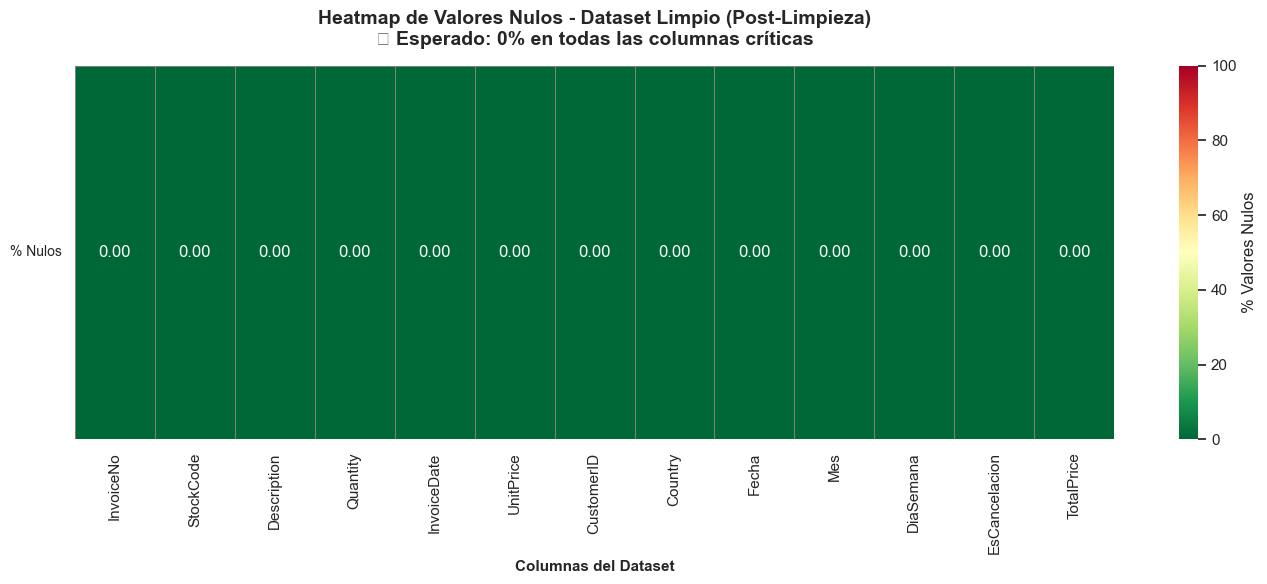

In [53]:
# 3.11.A — Heatmap de valores nulos post-limpieza

fig, ax = plt.subplots(figsize=(14, 6))

# Calcular porcentaje de nulos por columna
nulos_pct = (df_working.isnull().sum() / len(df_working) * 100).to_frame(name='% Nulos')

# Crear heatmap
sns.heatmap(
    nulos_pct.T,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    cbar_kws={'label': '% Valores Nulos'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0,
    vmax=100,
    ax=ax
)

ax.set_title(
    'Heatmap de Valores Nulos - Dataset Limpio (Post-Limpieza)\n'
    '✓ Esperado: 0% en todas las columnas críticas',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Columnas del Dataset', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_yticklabels(['% Nulos'], rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}heatmap_nulos_postlimpieza.png', dpi=300, bbox_inches='tight')
plt.show()

# Resumen textual
total_nulos = df_working.isnull().sum().sum()
print(f"{'='*60}")
print(f"  VERIFICACIÓN: VALORES NULOS POST-LIMPIEZA")
print(f"{'='*60}")
print(f"  Total valores nulos en dataset limpio: {total_nulos:,}")
if total_nulos == 0:
    print(f"  ✅ VALIDACIÓN EXITOSA: Dataset 100% completo")
else:
    print(f"  ⚠️  ATENCIÓN: Quedan {total_nulos:,} valores nulos")
    print(f"\n  Columnas con nulos:")
    for col, count in df_working.isnull().sum().items():
        if count > 0:
            pct = count / len(df_working) * 100
            print(f"    - {col}: {count:,} ({pct:.2f}%)")
print(f"{'='*60}")
print(f"\n  📁 Gráfico guardado: heatmap_nulos_postlimpieza.png")

### 3.11.B — Histogramas comparativos: Distribución bruta vs limpia

Comparación visual de las distribuciones de **Quantity** y **UnitPrice** antes y después de la limpieza. 

Permite observar:
- El efecto del **capping al p99** en las distribuciones (reducción de extremos)
- La eliminación de valores = 0 y negativos huérfanos
- La conservación de la forma general de la distribución (no distorsionada)

In [ ]:
# 3.11.B — Histogramas comparativos: Distribución bruta vs limpia

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Distribuciones Comparativas: Dataset Bruto vs Dataset Limpio\n'
    'Efecto de la limpieza y capping en Quantity y UnitPrice',
    fontsize=15,
    fontweight='bold',
    y=0.995
)

# ── QUANTITY: Dataset bruto (solo positivos para mejor visualización) ─────────
ax1 = axes[0, 0]
qty_raw_pos = df_raw[df_raw['Quantity'] > 0]['Quantity']
ax1.hist(qty_raw_pos, bins=100, color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.axvline(qty_raw_pos.quantile(0.99), color='red', linestyle='--', linewidth=2, 
            label=f'p99 = {qty_raw_pos.quantile(0.99):,.0f}')
ax1.set_title('Quantity - Dataset BRUTO (solo positivos)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Quantity', fontsize=10)
ax1.set_ylabel('Frecuencia', fontsize=10)
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
stats_text = f'n = {len(qty_raw_pos):,}\nMax = {qty_raw_pos.max():,.0f}\nMediana = {qty_raw_pos.median():,.0f}'
ax1.text(0.98, 0.97, stats_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── QUANTITY: Dataset limpio (solo positivos) ─────────────────────────────────
ax2 = axes[0, 1]
qty_clean_pos = df_working[df_working['Quantity'] > 0]['Quantity']
ax2.hist(qty_clean_pos, bins=100, color='lightgreen', alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.axvline(qty_clean_pos.max(), color='green', linestyle='--', linewidth=2, 
            label=f'Max (post-capping) = {qty_clean_pos.max():,.0f}')
ax2.set_title('Quantity - Dataset LIMPIO (solo positivos)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Quantity', fontsize=10)
ax2.set_ylabel('Frecuencia', fontsize=10)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)
stats_text = f'n = {len(qty_clean_pos):,}\nMax = {qty_clean_pos.max():,.0f}\nMediana = {qty_clean_pos.median():,.0f}'
ax2.text(0.98, 0.97, stats_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ── UNITPRICE: Dataset bruto ──────────────────────────────────────────────────
ax3 = axes[1, 0]
price_raw_pos = df_raw[df_raw['UnitPrice'] > 0]['UnitPrice']
# Filtrar outliers extremos para mejor visualización (hasta p99.5)
price_raw_vis = price_raw_pos[price_raw_pos <= price_raw_pos.quantile(0.995)]
ax3.hist(price_raw_vis, bins=100, color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axvline(price_raw_pos.quantile(0.99), color='red', linestyle='--', linewidth=2, 
            label=f'p99 = £{price_raw_pos.quantile(0.99):,.2f}')
ax3.set_title('UnitPrice - Dataset BRUTO (hasta p99.5 para visualización)', fontsize=12, fontweight='bold')
ax3.set_xlabel('UnitPrice (£)', fontsize=10)
ax3.set_ylabel('Frecuencia', fontsize=10)
ax3.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)
stats_text = f'n = {len(price_raw_pos):,}\nMax = £{price_raw_pos.max():,.2f}\nMediana = £{price_raw_pos.median():.2f}'
ax3.text(0.98, 0.97, stats_text, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── UNITPRICE: Dataset limpio ─────────────────────────────────────────────────
ax4 = axes[1, 1]
price_clean_pos = df_working[df_working['UnitPrice'] > 0]['UnitPrice']
ax4.hist(price_clean_pos, bins=100, color='lightgreen', alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axvline(price_clean_pos.max(), color='green', linestyle='--', linewidth=2, 
            label=f'Max (post-capping) = £{price_clean_pos.max():,.2f}')
ax4.set_title('UnitPrice - Dataset LIMPIO', fontsize=12, fontweight='bold')
ax4.set_xlabel('UnitPrice (£)', fontsize=10)
ax4.set_ylabel('Frecuencia', fontsize=10)
ax4.legend(loc='upper right')
ax4.grid(axis='y', alpha=0.3)
stats_text = f'n = {len(price_clean_pos):,}\nMax = £{price_clean_pos.max():,.2f}\nMediana = £{price_clean_pos.median():.2f}'
ax4.text(0.98, 0.97, stats_text, transform=ax4.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}histogramas_comparativos_bruto_vs_limpio.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"{'='*60}")
print(f"  ANÁLISIS: EFECTO DEL CAPPING")
print(f"{'='*60}")
print(f"  Quantity:")
print(f"    Bruto  - Max: {qty_raw_pos.max():>10,.0f}  |  Mediana: {qty_raw_pos.median():>8,.0f}")
print(f"    Limpio - Max: {qty_clean_pos.max():>10,.0f}  |  Mediana: {qty_clean_pos.median():>8,.0f}")
print(f"    Reducción máximo: {qty_raw_pos.max() - qty_clean_pos.max():>10,.0f} unidades")
print()
print(f"  UnitPrice:")
print(f"    Bruto  - Max: £{price_raw_pos.max():>10,.2f}  |  Mediana: £{price_raw_pos.median():>7.2f}")
print(f"    Limpio - Max: £{price_clean_pos.max():>10,.2f}  |  Mediana: £{price_clean_pos.median():>7.2f}")
print(f"    Reducción máximo: £{price_raw_pos.max() - price_clean_pos.max():>10,.2f}")
print(f"{'='*60}")
print(f"  ✓ Las medianas se mantienen → distribución preservada")
print(f"  ✓ Solo se ajustaron extremos del 1% superior")
print(f"{'='*60}")
print(f"\n  📁 Gráfico guardado: histogramas_comparativos_bruto_vs_limpio.png")

### 3.11.C — Pie Chart: Balance datos conservados vs eliminados

Visualización del impacto global de la limpieza: qué porcentaje del dataset original se conservó vs se eliminó.

Esta métrica es clave para evaluar si la estrategia de limpieza fue:
- **Demasiado agresiva** (< 60% conservado → pérdida excesiva de información)
- **Equilibrada** (60-80% conservado → balance óptimo calidad/cantidad)
- **Demasiado permisiva** (> 90% conservado → posible calidad insuficiente)

In [ ]:
# 3.11.C — Pie Chart: Balance datos conservados vs eliminados

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Balance Global de la Limpieza: Datos Conservados vs Eliminados',
    fontsize=15,
    fontweight='bold',
    y=0.98
)

# ── PIE CHART 1: Filas conservadas vs eliminadas ──────────────────────────────
filas_iniciales = stats_cleaning['Registros Iniciales']
filas_finales = len(df_working)
filas_eliminadas = filas_iniciales - filas_finales
pct_conservadas = (filas_finales / filas_iniciales * 100)
pct_eliminadas = (filas_eliminadas / filas_iniciales * 100)

sizes1 = [filas_finales, filas_eliminadas]
labels1 = [
    f'Conservadas\n{filas_finales:,} filas\n({pct_conservadas:.2f}%)',
    f'Eliminadas\n{filas_eliminadas:,} filas\n({pct_eliminadas:.2f}%)'
]
colors1 = ['#90EE90', '#FF6B6B']  # Verde claro, Rojo claro
explode1 = (0.05, 0)  # Destacar conservadas

wedges1, texts1, autotexts1 = ax1.pie(
    sizes1,
    labels=labels1,
    colors=colors1,
    explode=explode1,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    shadow=True
)

# Estilo de los porcentajes
for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

ax1.set_title('FILAS: Conservadas vs Eliminadas', fontsize=13, fontweight='bold', pad=20)

# ── PIE CHART 2: Desglose de filas eliminadas por paso ────────────────────────
pasos_eliminacion = {
    'Duplicados': stats_cleaning.get('Duplicados eliminados', 0),
    'Negativos huérfanos': stats_cleaning.get('Negativos huérfanos eliminados', 0),
    'StockCodes no estándar': stats_cleaning.get('StockCodes no estándar eliminados', 0),
    'Quantity = 0': stats_cleaning.get('Quantity = 0 eliminados', 0),
    'UnitPrice = 0': stats_cleaning.get('UnitPrice = 0 eliminados', 0),
    'CustomerID nulos': stats_cleaning.get('CustomerID nulos eliminados', 0),
    'Description nulas': stats_cleaning.get('Description nulas eliminadas', 0),
    'Duplicados post-capping': stats_cleaning.get('Duplicados post-capping eliminados', 0),
}

# Filtrar solo pasos que eliminaron algo
pasos_con_eliminaciones = {k: v for k, v in pasos_eliminacion.items() if v > 0}

if len(pasos_con_eliminaciones) > 0:
    sizes2 = list(pasos_con_eliminaciones.values())
    labels2 = [f'{k}\n({v:,})' for k, v in pasos_con_eliminaciones.items()]
    colors2 = plt.cm.Set3(range(len(sizes2)))
    
    wedges2, texts2, autotexts2 = ax2.pie(
        sizes2,
        labels=labels2,
        colors=colors2,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9},
        shadow=True
    )
    
    # Estilo de los porcentajes
    for autotext in autotexts2:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    
    ax2.set_title('DESGLOSE: Filas Eliminadas por Paso', fontsize=13, fontweight='bold', pad=20)
else:
    ax2.text(0.5, 0.5, 'No se eliminaron filas', 
             ha='center', va='center', fontsize=14, fontweight='bold')
    ax2.set_title('DESGLOSE: Filas Eliminadas por Paso', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}piechart_balance_conservadas_vs_eliminadas.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Resumen textual ───────────────────────────────────────────────────────────
print(f"{'='*70}")
print(f"  BALANCE GLOBAL DE LA LIMPIEZA")
print(f"{'='*70}")
print(f"  📊 RESUMEN:")
print(f"     Filas originales      : {filas_iniciales:>15,} (100.00%)")
print(f"     Filas conservadas     : {filas_finales:>15,} ({pct_conservadas:>6.2f}%)")
print(f"     Filas eliminadas      : {filas_eliminadas:>15,} ({pct_eliminadas:>6.2f}%)")
print(f"  {'-'*70}")

print(f"\n  📉 DESGLOSE DE ELIMINACIONES:")
total_check = 0
for paso, eliminadas in pasos_eliminacion.items():
    if eliminadas > 0:
        pct_del_total = (eliminadas / filas_iniciales * 100)
        pct_de_eliminadas = (eliminadas / filas_eliminadas * 100) if filas_eliminadas > 0 else 0
        print(f"     {paso:<25} : {eliminadas:>10,}  ({pct_del_total:>5.2f}% total, {pct_de_eliminadas:>5.2f}% eliminadas)")
        total_check += eliminadas

print(f"  {'-'*70}")
print(f"     TOTAL ELIMINADAS      : {total_check:>10,}")
print(f"  {'-'*70}")

# ── Evaluación de la estrategia ───────────────────────────────────────────────
print(f"\n  🎯 EVALUACIÓN DE LA ESTRATEGIA:")
if pct_conservadas >= 70 and pct_conservadas <= 80:
    evaluacion = "✅ ÓPTIMA - Balance ideal entre calidad y cantidad"
elif pct_conservadas > 80:
    evaluacion = "✅ BUENA - Alta retención de datos con calidad mejorada"
elif pct_conservadas >= 60:
    evaluacion = "⚠️  ACEPTABLE - Retención moderada, prioriza calidad"
else:
    evaluacion = "⚠️  AGRESIVA - Baja retención, revisar criterios"

print(f"     {evaluacion}")
print(f"     {pct_conservadas:.2f}% de datos conservados tras limpieza exhaustiva")
print(f"{'='*70}")
print(f"\n  📁 Gráfico guardado: piechart_balance_conservadas_vs_eliminadas.png")